In [ ]:
#Libraries
import numpy as np
import pandas as pd
import pymcel as pc
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import spiceypy as spy
from scipy.optimize import least_squares
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.cm as cm
import emcee

The purpose of this Notebook is to find the orbital elements of S4716 around the central black hole Sagittarius A* starting from the observatios made by the instruments NIRC2 (Keck), OSIRIS (Keck), SINFONI (VLT), NACO (VLT) and GRAVITY (VLTI) between 2003 and 2021. These are:

* $q$ - Periapsis distance
* $e$ - Eccentricity
* $i$ - Inclination
* $\Omega$ - Longitude of the ascending node
* $\omega$ - Argument of periapsis
* $t_p$ - Time of periapsis passage

## 1. Observed Data Adjustment

In this section, we analyze the observations and determine the ellipse that best describes those coordinates.

First we define the conversion variables:

In [42]:
d = 8000   #Distance to the center of the galaxy in Parsecs
grad = 1/3600   #convert arcseconds to degrees
rad = np.pi/180 #convert degrees to radians

#Parsecs
parsec = pc.constantes.pc

#Conversion factor from arcseconds to parsecs
factor = d*grad*rad * parsec

Very important to define the **canonical units**, wich are:

*  Distance: $1\text{ mpc}$ ($3.0857\times10^{13} \text{ m}$)
*  Mass: the mass of Sagittarius A* ($8.55\times10^{36} \text{ kg}$)

In [43]:
#Distance units (in meters)
ua = pc.constantes.au
parsec = pc.constantes.pc
mpc = parsec / 1000   #miliparsec
Msag_ = 4.3*1e6 * pc.constantes.M_sun

#CANONICAL UNITS
G = pc.constantes.G

UL = mpc
UM = Msag_

#CONVERSION from UL TO arcseg
factor2 = 1 / factor * UL

Then, the canonical units ($G = 1$) of time and speed are:

In [44]:
UT = (UL**3 / (G * UM))**(0.5)
UV = UL / UT

print(f"Canonical units of time: {UT:.3e} s")
print(f"Canonical units of velocity: {UV:.3e} m/s")

Canonical units of time: 7.175e+06 s
Canonical units of velocity: 4.300e+06 m/s


Let's import the observational coordinates (Right Ascension, RA, and Declination, Dec), as well as the observation dates:

In [45]:
dataframe = pd.read_csv("datos_s4716.csv")
dataframe.head()

,epoch,RA,Dec,err_RA,err_Dec
0,2003.44,-0.041,0.066,0.007,0.007
1,2005.26,-0.033,-0.002,0.007,0.007
2,2005.58,0.019,0.033,0.007,0.007
3,2006.33,-0.015,0.077,0.007,0.007
4,2007.25,-0.039,0.073,0.007,0.007


Plot of the observed coordinates and their associated uncertainties:

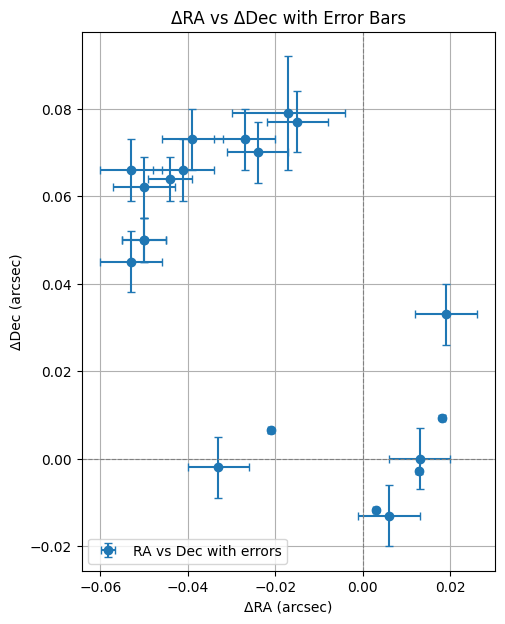

In [46]:
dRA = dataframe["RA"]
dDec = dataframe["Dec"]
err_dRA = dataframe["err_RA"]
err_dDec = dataframe["err_Dec"]

plt.figure(figsize=(10, 7))
plt.errorbar(dRA, dDec, xerr=err_dRA, yerr=err_dDec, fmt='o', capsize=3, label='RA vs Dec with errors')
plt.xlabel('ΔRA (arcsec)')
plt.ylabel('ΔDec (arcsec)')
plt.title('ΔRA vs ΔDec with Error Bars')
plt.grid(True)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.gca().set_aspect('equal', adjustable='box') # Add this line to make axes proportional
plt.legend()
plt.show()

Coordinates vs Time:

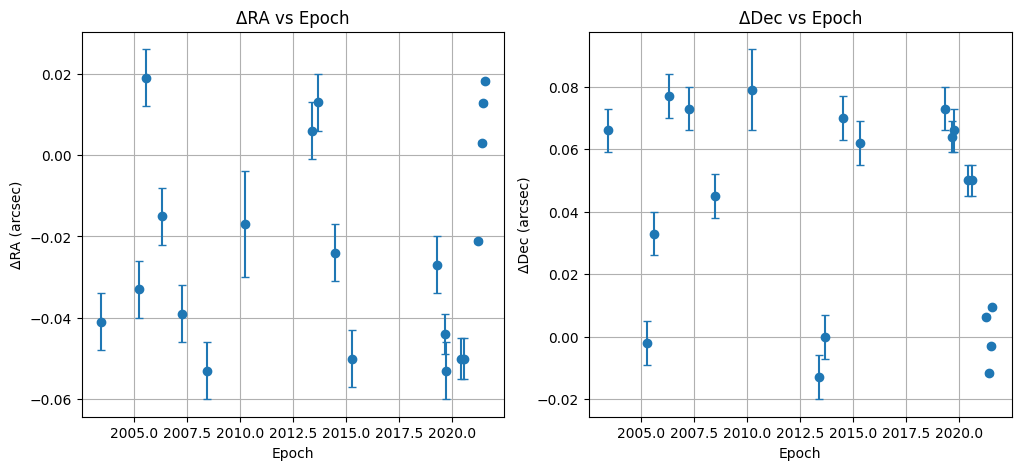

In [47]:
fig,axs = plt.subplots(1,2,figsize=(12,5))

axs[0].errorbar(dataframe.epoch, dataframe.RA, yerr=dataframe.err_RA, fmt='o', capsize=3)
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("ΔRA (arcsec)")
axs[0].set_title("ΔRA vs Epoch")
axs[0].grid(True)

axs[1].errorbar(dataframe.epoch, dataframe.Dec, yerr=dataframe.err_Dec, fmt='o', capsize=3)
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("ΔDec (arcsec)")
axs[1].set_title("ΔDec vs Epoch")
axs[1].grid(True)

Now, we use the Fitzgibbon method (this algorithm is easyly found on the internet) to find the ellipse that best describes the observations, since traditional methods do not yield good results. The uncertainties were not taken into account for this process:

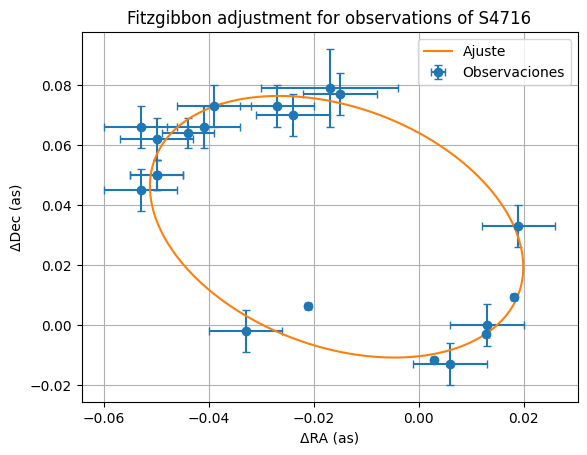

In [48]:
def fit_ellipse(x, y):
    """
    Fit the coefficients a,b,c,d,e,f, representing an ellipse described by
    the formula F(x,y) = ax^2 + bxy + cy^2 + dx + ey + f = 0 to the provided
    arrays of data points x=[x1, x2, ..., xn] and y=[y1, y2, ..., yn].

    Based on the algorithm of Halir and Flusser, "Numerically stable direct
    least squares fitting of ellipses'.
    """


    D1 = np.vstack([x**2, x*y, y**2]).T
    D2 = np.vstack([x, y, np.ones(len(x))]).T
    S1 = D1.T @ D1
    S2 = D1.T @ D2
    S3 = D2.T @ D2
    T = -np.linalg.inv(S3) @ S2.T
    M = S1 + S2 @ T
    C = np.array(((0, 0, 2), (0, -1, 0), (2, 0, 0)), dtype=float)
    M = np.linalg.inv(C) @ M
    eigval, eigvec = np.linalg.eig(M)
    con = 4 * eigvec[0]* eigvec[2] - eigvec[1]**2
    ak = eigvec[:, np.nonzero(con > 0)[0]]
    return np.concatenate((ak, T @ ak)).ravel()

def cart_to_pol(coeffs):
    """

    Convert the cartesian conic coefficients, (a, b, c, d, e, f), to the
    ellipse parameters, where F(x, y) = ax^2 + bxy + cy^2 + dx + ey + f = 0.
    The returned parameters are x0, y0, ap, bp, e, phi, where (x0, y0) is the
    ellipse centre; (ap, bp) are the semi-major and semi-minor axes,
    respectively; e is the eccentricity; and phi is the rotation of the semi-
    major axis from the x-axis.

    """

    # We use the formulas from https://mathworld.wolfram.com/Ellipse.html
    # which assumes a cartesian form ax^2 + 2bxy + cy^2 + 2dx + 2fy + g = 0.
    # Therefore, rename and scale b, d and f appropriately.
    a = coeffs[0]
    b = coeffs[1] / 2
    c = coeffs[2]
    d = coeffs[3] / 2
    f = coeffs[4] / 2
    g = coeffs[5]

    den = b**2 - a*c
    if den > 0:
        raise ValueError('coeffs do not represent an ellipse: b^2 - 4ac must'
                         ' be negative!')

    # The location of the ellipse centre.
    x0, y0 = (c*d - b*f) / den, (a*f - b*d) / den

    num = 2 * (a*f**2 + c*d**2 + g*b**2 - 2*b*d*f - a*c*g)
    fac = np.sqrt((a - c)**2 + 4*b**2)
    # The semi-major and semi-minor axis lengths (these are not sorted).
    ap = np.sqrt(num / den / (fac - a - c))
    bp = np.sqrt(num / den / (-fac - a - c))

    # Sort the semi-major and semi-minor axis lengths but keep track of
    # the original relative magnitudes of width and height.
    width_gt_height = True
    if ap < bp:
        width_gt_height = False
        ap, bp = bp, ap

    # The eccentricity.
    r = (bp/ap)**2
    if r > 1:
        r = 1/r
    e = np.sqrt(1 - r)

    # The angle of anticlockwise rotation of the major-axis from x-axis.
    if b == 0:
        phi = 0 if a < c else np.pi/2
    else:
        phi = np.arctan((2.*b) / (a - c)) / 2
        if a > c:
            phi += np.pi/2
    if not width_gt_height:
        # Ensure that phi is the angle to rotate to the semi-major axis.
        phi += np.pi/2
    phi = phi % np.pi

    return x0, y0, ap, bp, e, phi

def get_ellipse_pts(params, t):
    """
    Return npts points on the ellipse described by the params = x0, y0, ap,
    bp, e, phi for values of the parametric variable t between tmin and tmax.

    """

    x0, y0, ap, bp, e, phi = params
    # A grid of the parametric variable, t.
    t = t
    x = x0 + ap * np.cos(t) * np.cos(phi) - bp * np.sin(t) * np.sin(phi)
    y = y0 + ap * np.cos(t) * np.sin(phi) + bp * np.sin(t) * np.cos(phi)
    return x, y

x = dataframe["RA"]
y = dataframe["Dec"]
t_ = np.linspace(0, 2*np.pi, 10_000)   #angulo (anomalia media)
sigma = np.concatenate([err_dRA, err_dDec])

#Aplicar el método
coef = fit_ellipse(x,y)   #coeficientes a,b,c,d,e,f
params = cart_to_pol(coef)   #parámetros x0,y0,a,b,e,phi
x_fit, y_fit = get_ellipse_pts(params,t_)

#Graficar
plt.errorbar(dRA, dDec, xerr=err_dRA, yerr=err_dDec, fmt='o', capsize=3, label='Observaciones')
plt.plot(x_fit, y_fit, label="Ajuste")
plt.xlabel('ΔRA (as)')
plt.ylabel('ΔDec (as)')
#plt.gca().set_aspect('equal', adjustable='box') # Add this line to make axes proportional
plt.title("Fitzgibbon adjustment for observations of S4716")
plt.legend()
plt.grid()

Next we present the orbital elements reported by Peißker et al. (2022):

In [49]:
data_s4716 = {
    "Star": ["S4716"],
    "a": [1.94],          # mpc
    "e_a": [0.02],        # mpc
    "e": [0.756],
    "e_e": [0.02],
    "i": [161.13],        # degrees
    "e_i": [2.80],        # degrees
    "omega": [2.25],      # degrees (ω)
    "e_omega": [0.02],    # degrees
    "Omega": [153.55],    # degrees (Ω)
    "e_Omega": [1.54],    # degrees
    "Tclos": [2017.41],   # years (t_closest)
    "e_Tclos": [0.004]    # years
}

df = pd.DataFrame(data_s4716)
df

,Star,a,e_a,e,e_e,i,e_i,omega,e_omega,Omega,e_Omega,Tclos,e_Tclos
0,S4716,1.94,0.02,0.756,0.02,161.13,2.8,2.25,0.02,153.55,1.54,2017.41,0.004


Convert the dataframe values to canonical units and radians:

In [50]:
#Black hole mass in canonical units
Msag = Msag_ / UM

df["a"]=df["a"]* 1e-3*parsec / UL
df["e_a"] = df["e_a"]* 1e-3*parsec / UL

df["i"] = df["i"]*rad
df["e_i"] = df["e_i"]*rad

df["omega"] = df["omega"]*rad
df["e_omega"] = df["e_omega"]*rad

df["Omega"] = df["Omega"]*rad
df["e_Omega"] = df["e_Omega"]*rad

Before finding our own orbital elements, it is logical to visualize the orbit given by the orbital elements of Peißker et al. (2022). To achieve that, we use the `conics` function from the `SpiceyPy` library; therefore, it is necessary to calculate $q$. Similarly, we calculate the **angular velocity $n$** and the **orbital period $T$** (just in case).

Angular velocity:

$$
n^2 = \frac{\mu}{a^3}
$$


In [51]:
df["n"] = np.sqrt(Msag / df["a"]**3)   #Angular velocity

Semilatus rectum $p$ and periapsis distance $q$:

$$
p = a(1-e^2)
$$

$$
q = \frac{p}{1+e}
$$


In [52]:
df["p"] = df["a"]*(1-df["e"]**2)   #p
df["q"] = df["p"] / (1+df["e"])   #q

We calculate the orbital period $T$ using Kepler's third law (in canonical units):

$$
T = \left( \frac{a^3 4\pi ^2}{\mu} \right)^{1/2}
$$

In [53]:
df["T_"] = (4*np.pi**2 * df["a"]**3 / (Msag)) ** 0.5 #* UT /3600/24/365.25  #in case we want to see the orbital period in years
df

,Star,a,e_a,e,e_e,i,e_i,omega,e_omega,Omega,e_Omega,Tclos,e_Tclos,n,p,q,T_
0,S4716,1.94,0.02,0.756,0.02,2.812249,0.048869,0.03927,0.000349,2.679953,0.026878,2017.41,0.004,0.370082,0.83122,0.47336,16.977841


Let's create the vector V whose components are the orbital elements $q$, $e$, $i$, $\Omega$, $\omega$, $t_p$:

In [54]:
tp = df.iloc[0]["Tclos"] * pc.constantes.año / UT   #periapsis date
V = [df.iloc[0]["q"], df.iloc[0]["e"], df.iloc[0]["i"], df.iloc[0]["Omega"], df.iloc[0]["omega"],tp]

From the orbital elements we obtain the X, Y, Z coordinates:

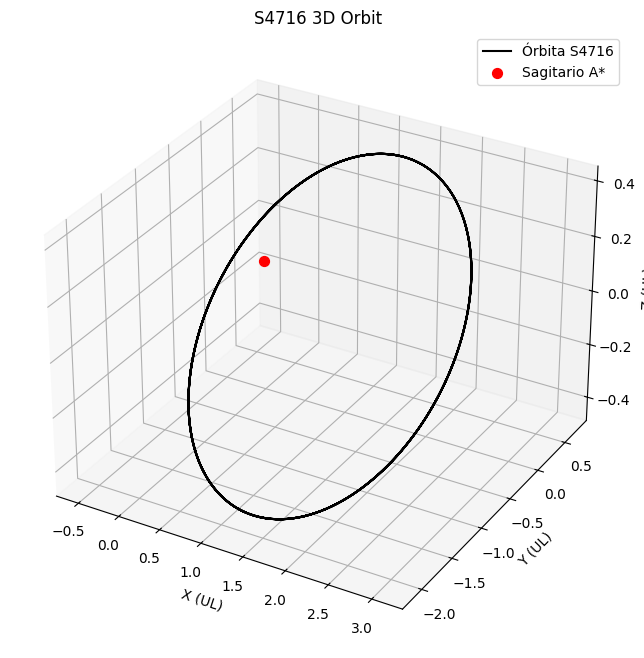

Total integration time: 18.1199999999999 years


In [55]:
#Time grid for integration
ts = np.linspace(dataframe.epoch.min(), dataframe.epoch.max(), 1000) * pc.constantes.año / UT

def posiciones(V, data=None):
  # Orbital elements
  X = list(V[0:5]) + [0] + [V[5]] + [Msag]
  ts = np.linspace(data.epoch.min(), data.epoch.max(), 1000) * pc.constantes.año / UT

  pos = np.zeros((len(ts),3))
  for i in range(len(ts)):
    t = ts[i]

    r = spy.conics(X,t)
    x = r[0]
    y = r[1]
    z = r[2]

    pos[i] = [x, y, z]
  return pos
orbitas = posiciones(V, data=dataframe)   #positions

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')
ax.plot(orbitas[:, 0], orbitas[:, 1], orbitas[:, 2], '-', color='black', label='Órbita S4716')
ax.scatter([0], [0], [0], color='red', s=50, label='Sagitario A*')
ax.set_xlabel('X (UL)')
ax.set_ylabel('Y (UL)')
ax.set_zlabel('Z (UL)')
ax.set_title('S4716 3D Orbit')
ax.legend()
plt.show() 

print(f"Total integration time: {(ts[-1] - ts[0]) * UT/3600/24/365.25} years")

Evolution of the X and Y coordinates as a function of time, along with the observations:

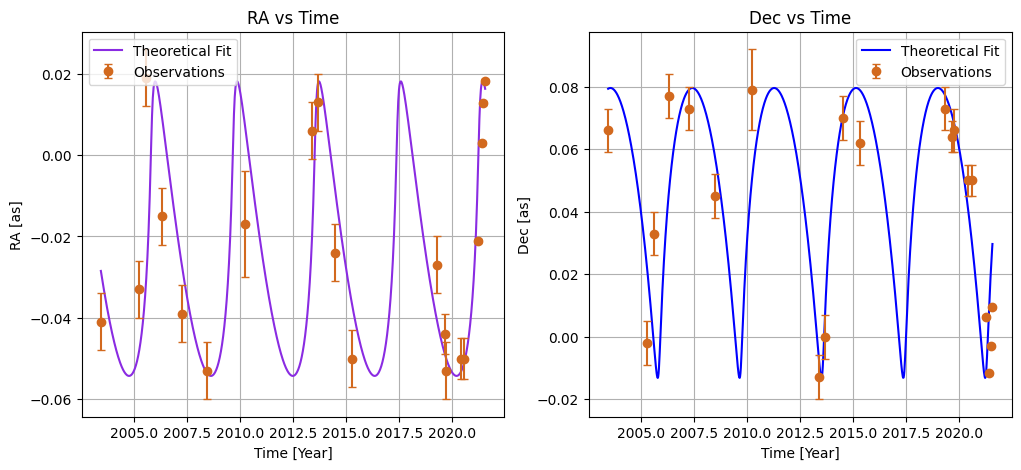

In [56]:
def plot_ajuste(V, data):
  '''
  This function generates a fit plot of the RA and Dec positions for the star S4716 as 
  a function of time, using the orbital elements provided in the vector V. Theoretical 
  RA and Dec positions are calculated from the orbital elements and compared with the 
  observational data, including error bars.

  Inputs:
  - V: Vector of orbital elements [q, e, i, Omega, omega, tp].
  - data: DataFrame containing the RA, Dec observations and their errors, as well as
    the observation times (epoch).

  Returns:
  - A plot with two subplots: one for RA vs time and another for Dec vs time, showing 
    both the theoretical positions and the observations with their errors.
  '''

  # Orbital elements
  tp = df.Tclos.iloc[0] * pc.constantes.año / UT   #periapsis time
  X = list(V[0:5]) + [0] + [V[5]] + [Msag]
  ts = np.linspace(data.epoch.min(), data.epoch.max(), 1000) * pc.constantes.año / UT

  dras_teo = []
  ddecs_teo = []
  for t in ts:
    r = spy.conics(X,t)
    dra_teo = r[1] * factor2   #ra according to the orbital elements
    ddec_teo = r[0] * factor2  #dec according to the orbital elements

    dras_teo += [dra_teo]
    ddecs_teo += [ddec_teo]
  
  error_RA = data.err_RA
  error_Dec = data.err_Dec

  fig, axs = plt.subplots(1, 2, figsize=(12, 5))
  axs[0].plot(ts * UT / pc.constantes.año, dras_teo,'-', color='blueviolet', label='Theoretical Fit')
  axs[1].plot(ts * UT / pc.constantes.año, ddecs_teo, 'b-', label='Theoretical Fit')
  axs[0].errorbar(data.epoch, data.RA, yerr=error_RA, fmt='o', capsize=3, label='Observations', color = "chocolate")
  axs[1].errorbar(data.epoch, data.Dec, yerr=error_Dec, fmt='o', capsize=3, label='Observations', color = "chocolate")

  # Labels
  axs[0].set_ylabel('RA [as]')
  axs[1].set_ylabel('Dec [as]')
  axs[0].set_xlabel('Time [Year]')
  axs[1].set_xlabel('Time [Year]')

  axs[0].set_title('RA and Dec vs Time')
  axs[0].set_title('RA vs Time')
  axs[1].set_title('Dec vs Time')
  axs[0].grid()
  axs[1].grid()
  axs[0].legend()
  axs[1].legend()

plot_ajuste(V, data=dataframe)

Now we can see the orbit in the sky:

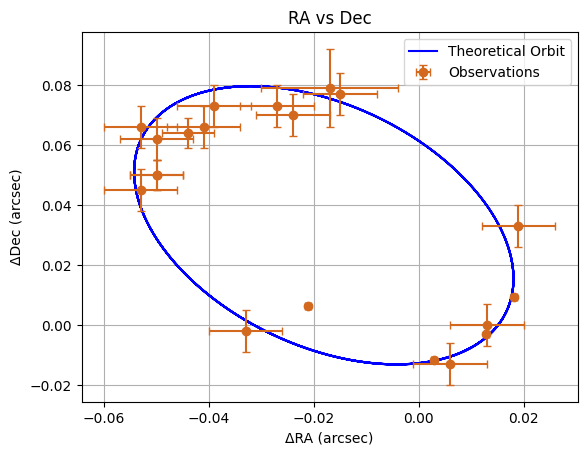

In [57]:
plt.plot(orbitas[:,1] * factor2,orbitas[:,0] * factor2, label="Theoretical Orbit", color="blue")
plt.errorbar(dRA, dDec, xerr=err_dRA, yerr=err_dDec, fmt='o', capsize=3,label="Observations", color="chocolate")
plt.xlabel("ΔRA (arcsec)")
plt.ylabel("ΔDec (arcsec)")
plt.title("RA vs Dec")
plt.legend()
plt.grid()


## Finding the orbital elements

This problem was approached by using the following function:

$$
\chi^2_{\nu} = \frac{1}{\nu}\sum_i\left( \frac{x_{obs,i} - x_{teo,i}}{\delta x_{obs}}\right)^2
$$

$x_{obs}$ is the observed coordinate, $x_{teo}$ is the coordinate generated by the orbital elements (theoretical orbit), $\delta x_{obs}$ is the uncertainty of $x_{obs}$ and $\nu$ is teh number of degrees of freedom given by $\nu = N - n$ where $N$ is the number of data points and $n$ is the number of parameters we want to estimate. Subsequently we search the parameters that minimize $\chi^2_{\nu}$ using the function `minimize` from `Scipy`. There are two different ways to define the corresponding $x_{teo}$ for each observation $x_{obs}$: taking time into account (**complete fit**) and only considering the spatial distribution (**spatial fit**). 


### Complete Fit

Since `conics` gives the coordinate position at a specific epoch, it is possible to precisely determine $x_{teo}$ for each $x_{obs}$ using the observation dates. We define the function `orbit_chisq`:

In [58]:
def orbit_chisq(V,data=None,  M=1, verbose=False):
  # Orbital elements
  X = list(V[0:5]) + [0] + [V[5]] + [Msag]

  chisq = 0
  for row in data.iterrows():
    t = row[1].epoch * pc.constantes.año / UT
    dra_obs = row[1].RA * factor / UL
    ddec_obs = row[1].Dec * factor / UL
    err_dra_obs = row[1].err_RA * factor / UL
    err_ddec_obs = row[1].err_Dec * factor / UL

    # For each time theoretical position
    #if verbose:
      #print(X, t)
    r = spy.conics(X,t)
    dra_teo = r[1]
    ddec_teo = r[0]

    gdl = len(data) - len(V)

    chisq += ((dra_obs - dra_teo) /err_dra_obs)**2+ ((ddec_obs - ddec_teo)/err_ddec_obs)**2 * 100 / gdl

    if verbose:
      print(dra_obs, ddec_obs, err_dra_obs, err_ddec_obs)
      print(dra_teo, ddec_teo)
      break

  return chisq

### Spatial Fit

In this case we generate the orbit using `conics`. Then, $x_{teo}$ corresponds to the point on the orbit closest to $x_{obs}$. It is important to note that when the orbit is generated whit a given set of orbital elements, the resulting urve consists of a finite set of discrete points. Consequently, simply selecting the nearest point to $x_{obs}$ is a biased criterion. Therefore, $x_{teo}$ was determined using a 3-point parabolic refinement method, which determines the vertex of the parabola formed by the three orbital points closest to each observation. This vertex represents a better approximation of the point of minimum distance. We define the function`orbit_chisq1`:

In [59]:
def orbit_chisq1(V,data=None, M=1):

  #Theoretical orbit given the orbital elements
  orbitas = posiciones(V, data=data)
  ra_teo = orbitas[:,1]
  dec_teo = orbitas[:,0]

  #Observations
  dras_obs = data['RA'].values * factor / UL
  ddecs_obs = data['Dec'].values * factor / UL
  err_dra_obs = data['err_RA'].values * factor / UL
  err_ddec_obs = data['err_Dec'].values * factor / UL

  dras_obs = np.array(dras_obs)
  ddecs_obs = np.array(ddecs_obs)
  err_dra_obs = np.array(err_dra_obs)
  err_ddec_obs = np.array(err_ddec_obs)

  # Theoretical point corresponding to each observation
  dx = ra_teo[:, np.newaxis] - dras_obs[np.newaxis, :]
  dy = dec_teo[:, np.newaxis] - ddecs_obs[np.newaxis, :]
  dist_sq = dx**2 + dy**2
    
  # Index of the closest discretized point
  indices = np.argmin(dist_sq, axis=0)
  indices = np.clip(indices, 1, len(ra_teo) - 2)

  # --- 3-point parabolic refinement ---
  # We avoid the absolute endpoints of the array to be able to select neighboring points.
  obs_idx = np.arange(len(dras_obs))

  # We valuate the squared distance at the minimum and its two neighbors
  f_m1 = dist_sq[indices - 1, obs_idx]
  f_0  = dist_sq[indices, obs_idx]
  f_p1 = dist_sq[indices + 1, obs_idx]

  # Cuadratic adjustment to find the real minimum between the points
  denom = f_p1 - 2 * f_0 + f_m1
  denom = np.where(denom == 0, 1e-10, denom) #If denom is zero, replace it with a small value to avoid division by zero
  delta = -0.5 * (f_p1 - f_m1) / denom
  delta = np.clip(delta, -0.5, 0.5) # Limit the adjustment to the space between points. f_0 is already the closest point, so we don't want to jump beyond the neighbors.

  # Interpolation of the exact theoretical positions using the continuous delta
  dras_teo = ra_teo[indices] + delta * (ra_teo[indices + 1] - ra_teo[indices - 1]) / 2
  ddecs_teo = dec_teo[indices] + delta * (dec_teo[indices + 1] - dec_teo[indices - 1]) / 2

  # Degrees of freedom and Chi-squared
  gdl = len(dras_obs) - len(V)  # Degrees of freedom: 2 observations per point minus adjusted parameters
  chisq = np.sum(((dras_obs - dras_teo)/ err_dra_obs)**2  + 
                   ((ddecs_obs - ddecs_teo) / err_ddec_obs)**2) * 100 / gdl

  return chisq

Below, we implement a routine that plots the orbit for a given set of orbital elements, mapping each $x_{obs}$ to its corresponding $x_{teo}$ using the *complete fit*.

In [60]:
from matplotlib.lines import Line2D

tiempo = dataframe.epoch * pc.constantes.año / UT

def grafico_orbita(elementos,dataframe, tiempo, title, verbose=False):    
    X_samples = list(elementos[0:5]) + [0] + [elementos[5]] + [Msag]
    colors = cm.viridis(np.linspace(0, 1, len(tiempo)))
    
    plt.figure(figsize=(10, 8))
    for i in range(len(tiempo)):
        t = tiempo[i]
        r = spy.conics(X_samples,t)   #This outputs positions in UL

        dra_teo = r[1] * factor2
        ddec_teo = r[0] * factor2

        dra_obs = dataframe.RA[i] 
        ddec_obs = dataframe.Dec[i] 

        plt.plot(dra_teo , ddec_teo,"o", color=colors[i])
        plt.plot(dra_obs, ddec_obs, 'x', color=colors[i])
        plt.plot([dra_teo, dra_obs], [ddec_teo, ddec_obs], '-', color=colors[i])

    dras_teo = []
    ddecs_teo = []
    for t in ts:
        r = spy.conics(X_samples,t)
        dra_teo = r[1] * factor2
        ddec_teo = r[0] * factor2

        dras_teo += [dra_teo]
        ddecs_teo += [ddec_teo]
    
    dras_teo = np.array(dras_teo)
    ddecs_teo = np.array(ddecs_teo)

    plt.plot(dras_teo , ddecs_teo , label="Orbit - orbital elements",color="black")
    if verbose:
        plt.plot(x_fit , y_fit ,"--",color="gray" ,label="Fitzgibbon fit")
    plt.xlabel("\u0394RA (as)")
    plt.ylabel("\u0394Dec (as)")
    plt.grid(True)
    plt.title(title)
    plt.tight_layout()
    plt.axis('equal') 

    legend_elements = [
    Line2D([0], [0], marker='x', color='k',
           markerfacecolor='k', markersize=8, label='Observations'),
    Line2D([0], [0], marker='o', color='k',
           linestyle='None', markersize=8, label='Theoretical Data'),
    Line2D([0], [0], color='k', linestyle='-',
           linewidth=2, label='Orbit - Orbital Elements'),
]

    plt.legend(handles=legend_elements)
    plt.show()

### Initial parameter estimation.

`minimize` requires an initial parameter estimate, which is determined strategically:

1. Starting with the curve given by the Fitzgibbon method and aplying geometric relations to the fitted ellipse we find $e$, $q$ and the ellipse foci of the ellipse.

Eccentricity: 0.729911
Position of the foci: F1 = (-0.031725, 0.062602), F2 = (0.000422, 0.002859)
Periapsis distance: 0.486831


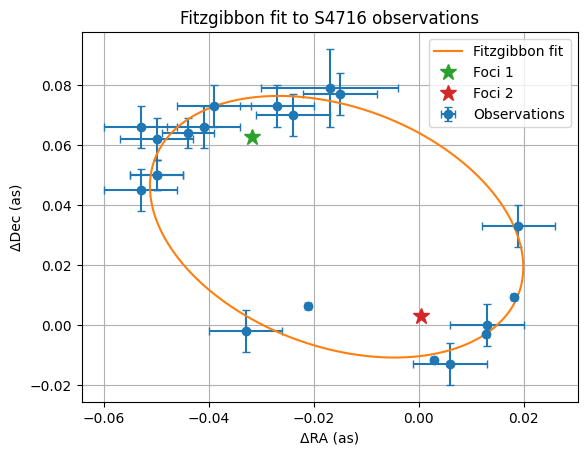

In [61]:
coef_fit_xy = fit_ellipse(x_fit, y_fit)
x0_fit, y0_fit, semi_major, semi_minor, e_gess, theta = cart_to_pol(coef_fit_xy)   #x0_fit,y0_fit ---> centro de la elipse

c = np.sqrt( semi_major**2 - semi_minor**2)   #femi focal distance

#Foci
focus1 = (x0_fit + c * np.cos(theta), y0_fit + c * np.sin(theta))
focus2 = (x0_fit - c * np.cos(theta), y0_fit - c * np.sin(theta))

#Periapsis distance
q_gess = min(np.sqrt((x_fit - focus1[0])**2 + (y_fit - focus1[1])**2)) * factor / UL

print(f"Eccentricity: {e_gess:.6f}")
print(f"Position of the foci: F1 = ({focus1[0]:.6f}, {focus1[1]:.6f}), F2 = ({focus2[0]:.6f}, {focus2[1]:.6f})")
print(f"Periapsis distance: {q_gess:.6f}")

plt.errorbar(dataframe.RA, dataframe.Dec, xerr=dataframe.err_RA, yerr=dataframe.err_Dec, fmt='o', capsize=3, label='Observations')
plt.plot(x_fit, y_fit, label="Fitzgibbon fit")
plt.plot(focus1[0], focus1[1], marker='*', markersize=12, linestyle='None', label='Foci 1')
plt.plot(focus2[0], focus2[1], marker='*', markersize=12, linestyle='None', label='Foci 2')
plt.xlabel("ΔRA (as)")
plt.ylabel("ΔDec (as)")
plt.title("Fitzgibbon fit to S4716 observations")
plt.grid()
plt.legend(loc='upper right')
plt.show()

2. Focus 2 (represented by the *focus2* variable) is identified as the location of Sagittarius A* due to its proximity to the origin of the reference frame and the fact that the star exhibits its highest apparent velocity in this vicinity, as expected for the periapsis. By computing the distance from each observation to this focus, we identify the observation closest to the periapsis. The epoch corresponding to this observation is adopted as the initial estimate for $t_p$.

In [62]:
#PERIAPSIS DATE
dist_focus1 = np.sqrt((dataframe.RA.values - focus1[0])**2 + (dataframe.Dec.values - focus1[1])**2)
dist_focus2 = np.sqrt((dataframe.RA.values - focus2[0])**2 + (dataframe.Dec.values - focus2[1])**2)

indice_min1 = np.argmin(dist_focus1)
indice_min2 = np.argmin(dist_focus2)

t_gess = dataframe.epoch.values[indice_min2] * pc.constantes.año / UT
print(f"Periapsis date (according to focus 2): {t_gess * UT / pc.constantes.año:.2f} ")

Periapsis date (according to focus 2): 2013.66 


3. The exact values of the orientation angles ($i$, $\Omega$, and $\omega$) cannot be determined only from the 2D projection of the ellipse. Consequently, the best approach is to constrain their plausible ranges based on the curve obtained from the Fitzgibbon fit and select an intermediate value to initialize the optimization. The assumed bounds are:

    * $i$ $\in$ [$\pi$/2, $\pi$]
    * $\Omega$ $\in$ [0, $\pi$]
    * $\omega$ $\in$ [0, $\pi$]

Since we are performig a 2D spatial fit, it is completely equivalent to select either the $[0, \pi/2]$ or $[\pi/2, \pi]$ interval for the inclination $i$. 

In [63]:
#Array or the first guess for the orbital elements
gess_elements = [q_gess, e_gess, 135*rad, 135*rad, 45*rad, t_gess]   #q, e, i, Omega, omega, tp

### Minimization of `orbit_chisq` 

In [64]:
#Range of the orbital elements for the optimization
bounds = [
    (0.4, 0.7),      # q > 0
    (0, 0.9),     # 0 <= e < 1
    (np.pi/2, np.pi),     # i
    (0.001, np.pi),   # Omega
    (0.001, np.pi),   # omega
    (8809.45,8888.62 )   #Periapsis date (between 2003 and 2021)
]

iters = int(100)
for i in range(iters):
    res = minimize(
    orbit_chisq,
    np.array(gess_elements),
    args=(dataframe, Msag, False),
    method='L-BFGS-B',
    bounds=bounds
)
    gess_elements = res.x

V_min = gess_elements

In [65]:
print(f"Optimized orbital elements (complete fit):")
print(f"q: {V_min[0]:.3f} mpc")
print(f"e: {V_min[1]:.3f}")
print(f"i: {V_min[2]:.3f} rad")
print(f"Omega: {V_min[3]:.3f} rad")
print(f"omega: {V_min[4]:.3f} rad")
print(f"tp: {V_min[5]*UT/pc.constantes.año:.3f}")

Optimized orbital elements (complete fit):
q: 0.400 mpc
e: 0.000
i: 3.142 rad
Omega: 0.001 rad
omega: 3.142 rad
tp: 2002.998


RA and Dec over time, calculated using the derived orbital elements (complete fit):

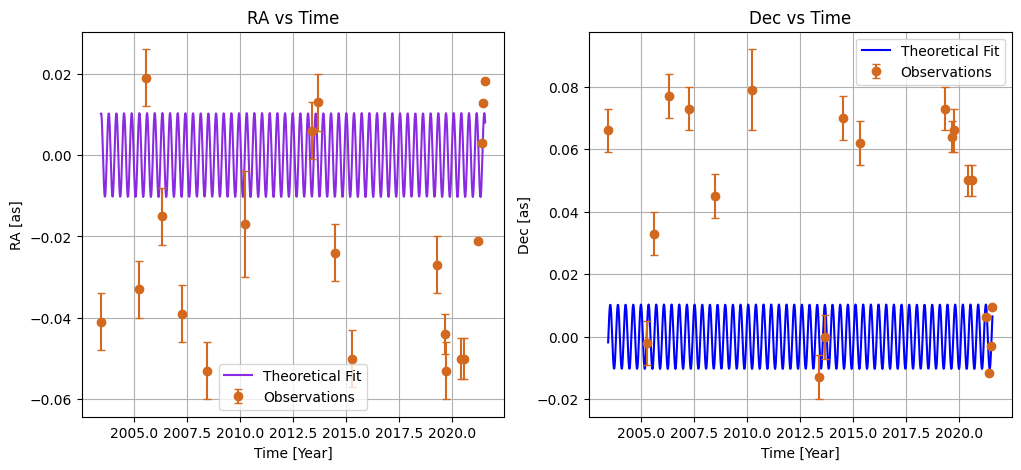

In [66]:
plot_ajuste(V_min, data=dataframe)

Orbit in the sky. We apply the function `grafico_orbita` to relate each observation with its corresponding coordinate given by the orbital elements.

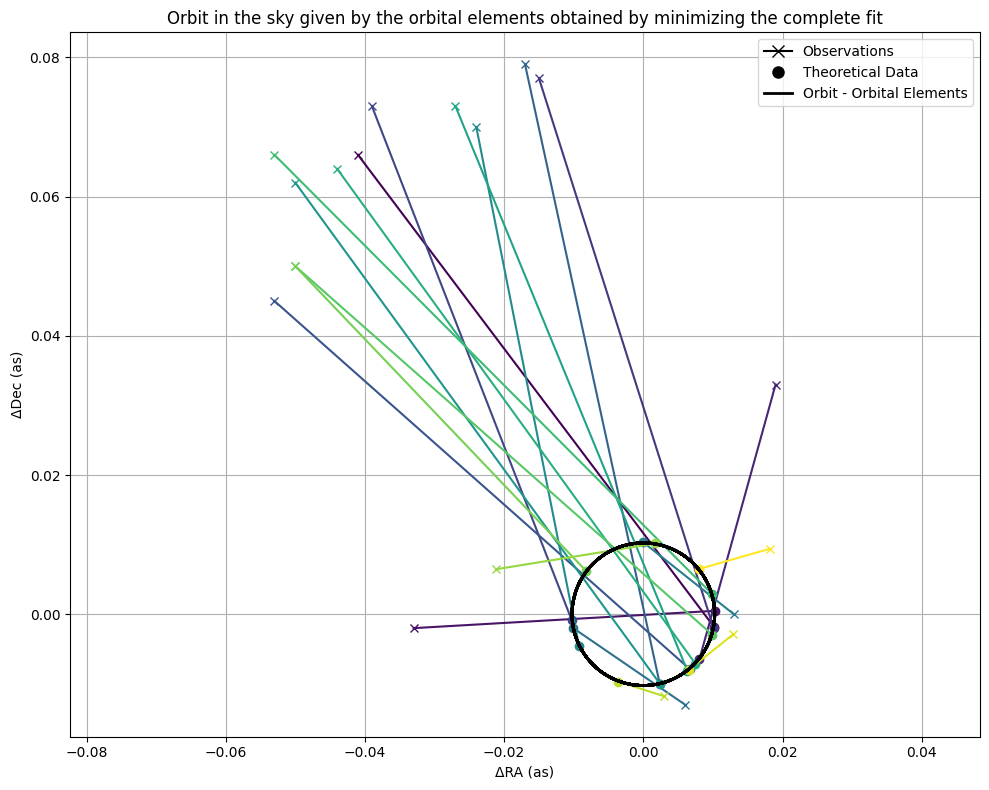

In [70]:
title1 = "Orbit in the sky given by the orbital elements obtained by minimizing the complete fit"
grafico_orbita(V_min, dataframe, tiempo, title=title1, verbose=False)

### Minimization of `orbit_chisq1`

In [71]:
gess_elements =  [q_gess, e_gess, 135*rad, 120*rad, 120*rad, t_gess]   #q, e, i, Omega, omega, tp
iters = int(1)
for i in range(iters):
    res1 = minimize(
    orbit_chisq1,
    np.array(gess_elements),
    args=(dataframe, Msag),
    method='L-BFGS-B',
    bounds=bounds
)
    gess_elements = res1.x

V_min1 = gess_elements

In [72]:
print(f"Optimized orbital elements (spatial fit):")
print(f"q: {V_min1[0]:.3f} mpc")
print(f"e: {V_min1[1]:.3f}")
print(f"i: {V_min1[2]:.3f} rad")
print(f"Omega: {V_min1[3]:.3f} rad")
print(f"omega: {V_min1[4]:.3f} rad")
print(f"tp: {V_min1[5]*UT/pc.constantes.año:.3f}")

Optimized orbital elements (spatial fit):
q: 0.461 mpc
e: 0.769
i: 2.443 rad
Omega: 2.927 rad
omega: 0.001 rad
tp: 2020.999


RA and Dec over time, calculated using the derived orbital elements (spatial fit):

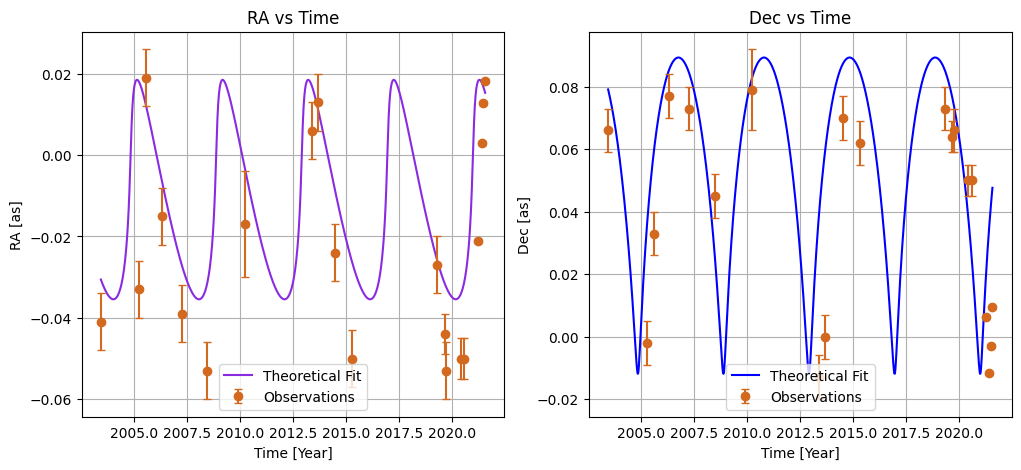

In [73]:
plot_ajuste(V_min1, data=dataframe)

Orbit in the sky. We apply again the function `grafico_orbita`:

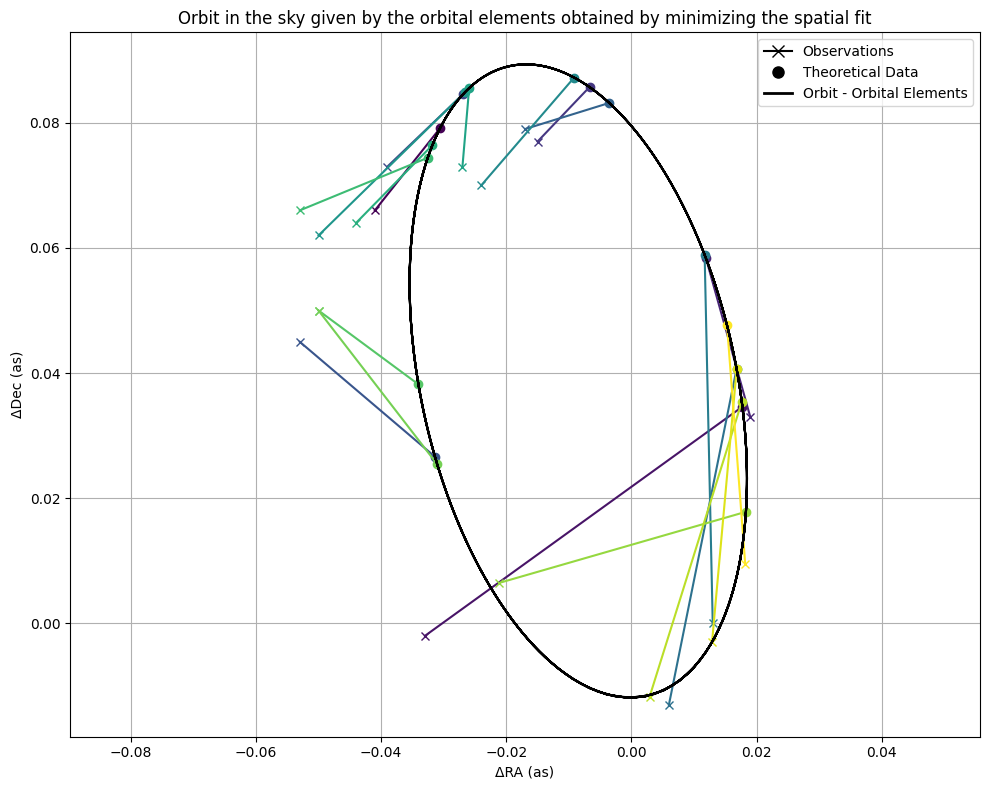

In [76]:
title2 = "Orbit in the sky given by the orbital elements obtained by minimizing the spatial fit"
grafico_orbita(V_min1, dataframe, tiempo, title=title2, verbose=False)

## MCMC

The next step consists of refining the orbital elements using the Markov Chain Monte Carlo (MCMC) algorithm, which also allows for estimating the uncertainties of the fitted parameters. Because the goal is to obtain an orbit that simultaneously reproduces both the spatial distribution and the temporal evolution of the observations, this algorithm is applied to the complete fit. Of the two prior minimizations, the spatial fit yields the closest match to the orbit described by S4716. Consequently, its resulting parameters are adopted as the initial guess for the MCMC sampler.

**Prior Probability Density Function**

In [77]:
def log_prior(V):
  q, e, i, W, w, t_p = V
  t0 = 8809.45  #Year 2003 in canonical units
  tf = 8888.62   #Year 2021 in canonical units

  #LLimits
  if (0.4 < q < 0.7 and
        0 < e < 0.9 and
        np.pi/2 < i < np.pi and
        0.001 < W < np.pi and
        0.001 <= w < np.pi and
        t0 < t_p < tf):
    return 0.0 

  else:
    return -np.inf

**Likelihood Function**

In [78]:
def log_likelihood(V, data=None, M=1):
    t, obs_ra, obs_dec, e_ra, e_dec, norm = data

    #Orbital elements
    X = list(V[0:5]) + [0] + [V[5]] + [M]
    posiciones = np.array([spy.conics(X, ti) for ti in t])
    dra_teo = posiciones[:, 1]
    ddec_teo = posiciones[:, 0]

    #chi-squared calculation
    chisq = np.sum(((obs_ra - dra_teo)/e_ra)**2 + ((obs_dec - ddec_teo)/e_dec)**2)

    return -0.5 * (chisq + norm)

**Posterior Probability Function**

In [79]:
def log_probability(V, data=None,M=1):
    # 1. Evaluate the log prior
    lp = log_prior(V)

    # 2. If the prior is invalid (-inf), return immediately to avoid calculating the likelihood
    if not np.isfinite(lp):
        return -np.inf
    else:
        # 3. If the prior is valid (0.0), add the log likelihood
        # ln P(post) = ln P(prior) + ln P(likelihood)
        return lp + log_likelihood(V, data, M)

We define a funtion to run MCMC:

In [80]:
#Funtion to run MCMC
def run_mcmc(initial, data, M=1, nwalkers=32, nsteps=5000):
    ndim = len(initial)
    # Initialize the walkers in a small Gaussian ball around the initial guess
    pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)

    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(data,M))
    sampler.run_mcmc(pos, nsteps, progress=True)

    return sampler

Observational data is organize in arrays for computational efficiency :)

In [81]:
# Convert the observational data into vectors
epochs = dataframe.epoch.values * pc.constantes.año / UT
dra_obs = dataframe.RA.values * factor / UL
ddec_obs = dataframe.Dec.values * factor / UL
err_dra = dataframe.err_RA.values * factor / UL
err_ddec = dataframe.err_Dec.values * factor / UL

#Pre-compute the normalization term for the log prior
log_prior_norm = np.sum(np.log(2 * np.pi * err_dra**2) + np.log(2 * np.pi * err_ddec**2))

# Create a tuple containing the observational data and the normalization term
clean_data = (epochs, dra_obs, ddec_obs, err_dra, err_ddec, log_prior_norm)

Here we calculate the orbital period $T$ of S4716:

In [82]:
def periodo_orbital(V):
    q,e = V[0], V[1]
    a = q / (1 - e)      # Semieje mayor
    P = 2 * np.pi * np.sqrt(a**3)
    return P

# Ejemplo
P = periodo_orbital(V_min1)
print("Orbital period (years)=", f"{P * UT /pc.constantes.año:.3f}")

Orbital period (years)= 4.035


We run the MCMC sampler. We readjust the initial periapsis epoch parameter ($t_p$) using the orbital period ($P$). In principle, using $t_p$ or $t_p \pm P$ should be strictly equivalent because, for a periodic orbit, both values correspond to valid periapsis passage epochs. However, after multiple runs, we observed that the MCMC algorithm exhibits high sensitivity to the choice of $t_p$, leading to convergence issues or numerical errors for certain values. A deeper investigation into the possible causes of this behavior remains pending for future work.

In [84]:
V_min1[5] = V_min1[5] - P   #Readjust tp
V_inicial = V_min1 # We use the results from the previous optimization (spatial fit) as the initial guess

for i in range(1):
    sampler = run_mcmc(V_inicial, clean_data, M=Msag, nwalkers=50, nsteps=30_000)

    tau = sampler.get_autocorr_time(quiet=True)
    flat_samples = sampler.get_chain(discard=int(2*max(tau)), thin=int(max(tau)/2), flat=True)

    samples = np.percentile(flat_samples, [16, 50, 84], axis=0)
    final_samples = samples[1]  # The median of each parameter
    V_inicial = final_samples  # Update the initial data for the next iteration

100%|██████████| 30000/30000 [05:01<00:00, 99.63it/s] 


**Acceptance fraction** to see if the chain converged correctly. If so, it should lie between $0.2$ and $0.5$:

In [93]:
print(np.mean(sampler.acceptance_fraction))

0.4471386666666667


It seems okay. Let's see the final optimized parameters:

In [94]:
print(f"Orbital elements given by the MCMC refinement:")
print(f"q: {final_samples[0]:.3f} mpc")
print(f"e: {final_samples[1]:.3f}")
print(f"i: {final_samples[2]:.3f} rad")
print(f"Omega: {final_samples[3]:.3f} rad")
print(f"omega: {final_samples[4]:.3f} rad")
print(f"tp: {final_samples[5]*UT/pc.constantes.año:.3f}")

Orbital elements given by the MCMC refinement:
q: 0.402 mpc
e: 0.798
i: 2.587 rad
Omega: 2.857 rad
omega: 0.007 rad
tp: 2013.391


RA and Dec over time, calculated using the derived orbital elements (MCMC):

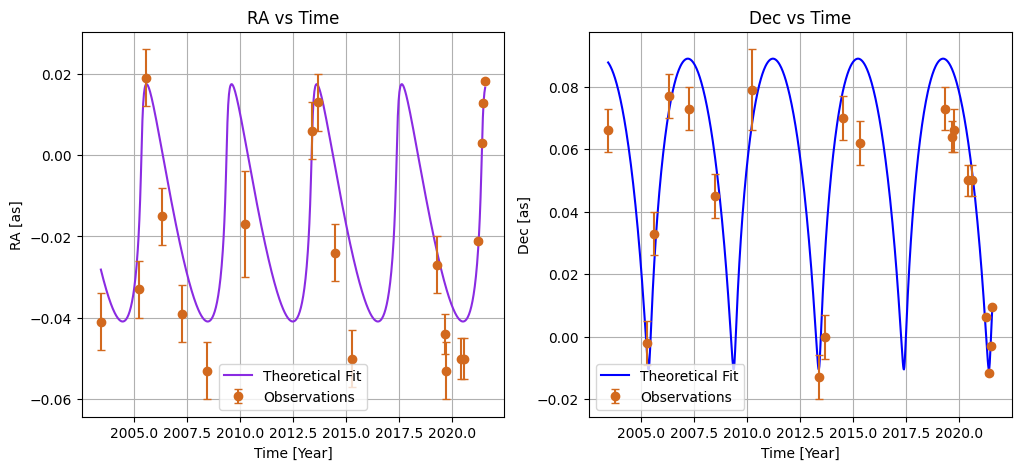

In [95]:
plot_ajuste(final_samples, data=dataframe)

Orbit in the sky:

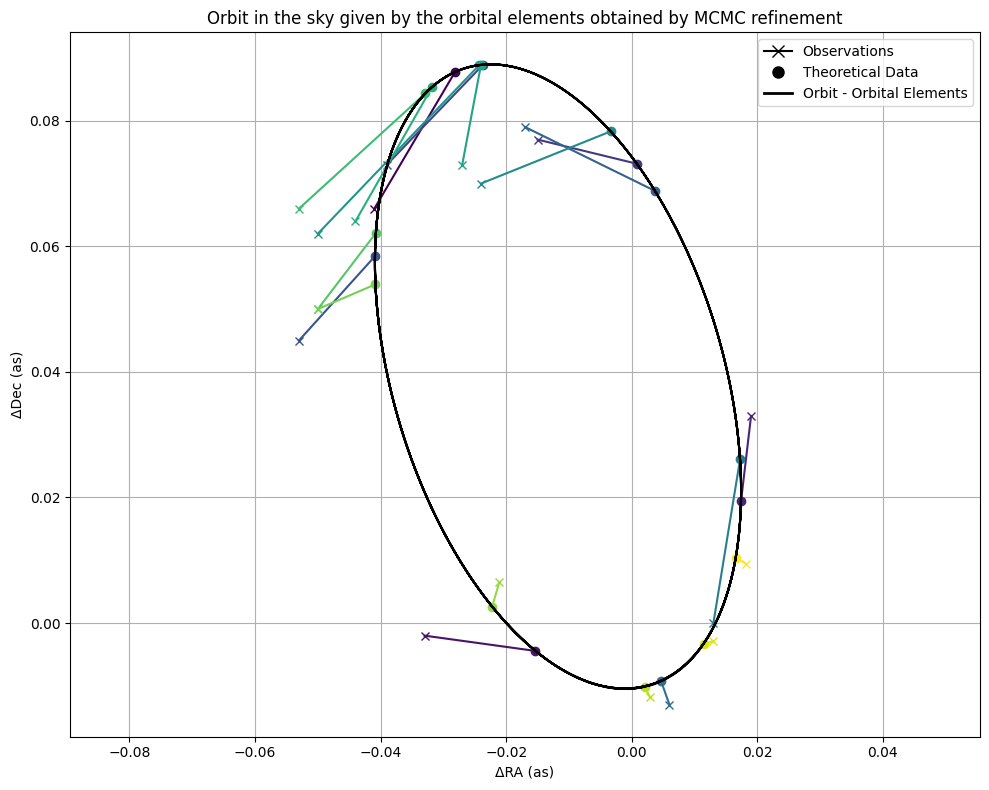

In [96]:
title3 = "Orbit in the sky given by the orbital elements obtained by MCMC refinement"
grafico_orbita(final_samples, dataframe, tiempo, title=title3, verbose=False)

### Uncertainties

As we stated before, the MCMC algorithm also provides the parameter uncertainties:

In [97]:
median = np.median(samples, axis=0)  #Final orbital parameters (median)
sigma  = np.std(samples, axis=0)   #Standard deviation of the final orbital parameters

labels=["a", "e", "i", "W", "w", "tp"]

e_final = np.array([median[1], sigma[1]]) 
#Degrees to radians
i_final = np.array([median[2], sigma[2]]) / rad
W_final = np.array([median[3], sigma[3]]) / rad
w_final = np.array([median[4], sigma[4]]) / rad
tp_final = np.array([median[5], sigma[5]]) * UT / pc.constantes.año

a_final_sigma = np.sqrt((1/(1-median[1])*sigma[0])**2 + (median[0]/(1-median[1])**2*sigma[1])**2)   #Uncertainty in the semi-major axis
a_final = np.array([median[0] / (1-median[1]), a_final_sigma] )  #Semi-major axis (already in mpc)

print("\nFinal orbital elements:\n")
print(f"a  = {a_final[0]:.5f} ± {a_final[1]:.5f} mpc")
print(f"e  = {e_final[0]:.5f} ± {e_final[1]:.5f}")
print(f"i  = {i_final[0]:.3f} ± {i_final[1]:.3f} deg")
print(f"Ω  = {W_final[0]:.3f} ± {W_final[1]:.3f} deg")
print(f"ω  = {w_final[0]:.3f} ± {w_final[1]:.3f} deg")
print(f"tp = {tp_final[0]:.3f} ± {tp_final[1]:.3f}")


Final orbital elements:

a  = 1.99046 ± 0.01270 mpc
e  = 0.79799 ± 0.00091
i  = 148.233 ± 1.306 deg
Ω  = 163.676 ± 0.857 deg
ω  = 0.402 ± 0.343 deg
tp = 2013.391 ± 0.010


Compared to the previous solutions obtained via $\chi^2$ minimization, the MCMC sampler yields a better fit for both the spatial distribution and temporal evolution of the observed data. To evaluate our results, we compute the reduced chi-squared ($\chi^2_{\nu}$) using its complete fit version (`orbit_chisq`) and compare the value obtained from the orbital elements we derive, with the one calculated for the orbital elements reported by Peißker et al. (2022):

In [98]:
print(f"Evaluated statistic for the orbital elements from Peißker et al. 2022: {orbit_chisq(V,data=dataframe, M=Msag, verbose=False)/100:.3f}")
print(f"Evaluated statistic for the final orbital elements: {orbit_chisq(V_min,data=dataframe, M=Msag, verbose=False)/100:.3f}")

Evaluated statistic for the orbital elements from Peißker et al. 2022: 539.048
Evaluated statistic for the final orbital elements: 142.937


The results show that, for the given observational data, the orbital elements obtained in this work give a better fit to the data. Comparing both orbital models graphically:

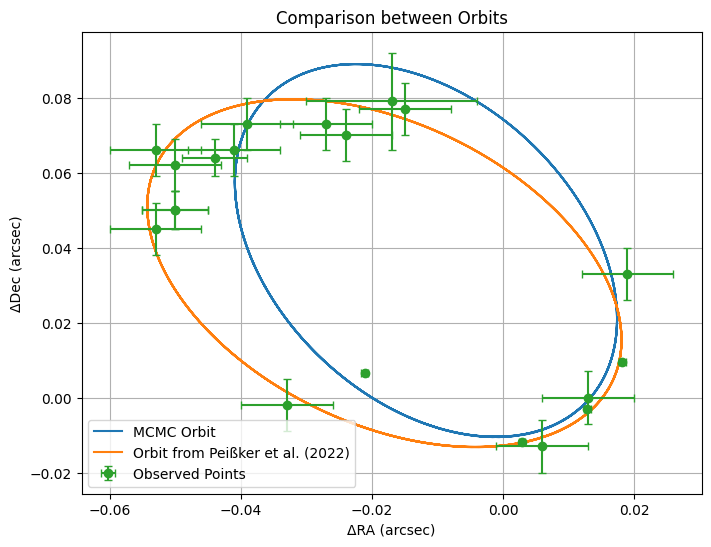

In [99]:
orbita1=posiciones(final_samples, data=dataframe)
orbita2=posiciones(V, data=dataframe)

plt.figure(figsize=(8, 6))
plt.plot(orbita1[:,1]*factor2, orbita1[:,0]*factor2, label="MCMC Orbit")
plt.plot(orbita2[:,1]*factor2, orbita2[:,0]*factor2, label="Orbit from Peißker et al. (2022)")
plt.errorbar(dataframe.RA, dataframe.Dec, xerr=dataframe.err_RA, yerr=dataframe.err_Dec, fmt='o', capsize=3,label="Observed Points")
plt.grid()
plt.title("Comparison between Orbits")
plt.xlabel("ΔRA (arcsec)")
plt.ylabel("ΔDec (arcsec)")
plt.legend()
plt.show()

From the plot, it is evident that the orbit reported by Peißker et al. (2022) traces the observational data more closely. This discrepancy may stem from differences in the fitting procedures and optimization routines employed in each work.